In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sales = pd.read_csv("sales_transactions.csv")
stores = pd.read_csv("store_info.csv")

In [3]:
# Addressing the store info csv first

# Missing values
print(stores.isnull().sum())

# Duplicate rows
print(stores.duplicated().sum())

# Unique values in important columns
print(stores["region"].unique())
print(stores["store_id"].unique())

store_id        0
region          0
manager         0
store_size      0
store_type      0
opening_year    0
dtype: int64
0
<StringArray>
[  'East',  'South',  'North',    ' E ', 'South ',  'SOUTH',    ' W ',
   'EAST',   'West',   'WEST']
Length: 10, dtype: str
<StringArray>
[     'S01',      'S02',      'S03', 'Store-04',      'S05',      'S06',
      'S07',      'S08',      'S09',       '10',      'S11',      'S12',
      'S13',      'S14',      'S15',      'S16',      'S17',      'S18',
       '19',      'S20',      'S21',      'S22',      'S23',      'S24',
      'S25',      'S26',      'S27',      'S28',      'S29',      'S30']
Length: 30, dtype: str


In [4]:
# The region names are inconsistent, need to standardize them
stores["region"] = (
    stores["region"]
    .str.strip()
    .replace({
        "E": "East",
        "EAST": "East",
        "SOUTH": "South",
        "W": "West",
        "WEST": "West"
    })
)

print(stores['region'].unique())

<StringArray>
['East', 'South', 'North', 'West']
Length: 4, dtype: str


In [5]:
# Store IDs are also inconsistent
# Most IDs follow the same format (SXX) but some are entered with only the number or with Store-XX
# Will change them all to have the same SXX form
def clean_store_id(store_id):
    # Remove "Store-" if present
    store_id = store_id.replace("Store-", "")

    # Remove leading S if present
    store_id = store_id.replace("S", "")

    # Convert to integer then back to S##
    return f"S{int(store_id):02d}"

stores["store_id"] = stores["store_id"].apply(clean_store_id)

In [6]:
print(stores["store_id"])

0     S01
1     S02
2     S03
3     S04
4     S05
5     S06
6     S07
7     S08
8     S09
9     S10
10    S11
11    S12
12    S13
13    S14
14    S15
15    S16
16    S17
17    S18
18    S19
19    S20
20    S21
21    S22
22    S23
23    S24
24    S25
25    S26
26    S27
27    S28
28    S29
29    S30
Name: store_id, dtype: str


In [7]:
# Final check to see how things look in the stores df
print(stores.head())

print(stores["region"].unique())
print(stores["store_id"].unique())
print(stores.isnull().sum())
print(stores.duplicated().sum())

  store_id region    manager store_size store_type  opening_year
0      S01   East  Manager_A     Medium     Street          2020
1      S02  South  Manager_B     Medium     Street          2017
2      S03  North  Manager_C      Large     Street          2020
3      S04   East  Manager_D      Large     Street          2009
4      S05   East  Manager_E      Small       Mall          2022
<StringArray>
['East', 'South', 'North', 'West']
Length: 4, dtype: str
<StringArray>
['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11',
 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22',
 'S23', 'S24', 'S25', 'S26', 'S27', 'S28', 'S29', 'S30']
Length: 30, dtype: str
store_id        0
region          0
manager         0
store_size      0
store_type      0
opening_year    0
dtype: int64
0


In [8]:
# Addressing the sales csv
sales.info()

sales.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 3085 entries, 0 to 3084
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   transaction_id    3085 non-null   str  
 1   store_id          3085 non-null   str  
 2   sale_date         3066 non-null   str  
 3   product_category  3085 non-null   str  
 4   quantity          3060 non-null   str  
 5   supplier          3085 non-null   str  
 6   region            3085 non-null   str  
 7   unit_cost         3032 non-null   str  
 8   unit_price        3085 non-null   str  
 9   inventory_level   3046 non-null   str  
 10  labour_hours      3053 non-null   str  
 11  labour_cost       3085 non-null   str  
dtypes: str(12)
memory usage: 289.3 KB


,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27 00:00:00,Sports,2,activepro,East,59.53,121.7,31,2.76,73.19 CAD
1,T000763,S18,2025-02-14 00:00:00,Beauty,2,Glow Works,West,17.62,40.84,10,NaN,119.32
2,T000623,S03,NaN,Electronics,1,NORTHSTAR,North,235.26,308.8,145,4.66,103.05
3,T000827,S27,2025-01-06 00:00:00,Grocery,2,FreshFarm,West,6.41,10.74,14,4.56,125.6
4,T000175,S01,2025-05-06 00:00:00,Electronics,8,NorthStar,East,231.33,289.13,48,5.34,113.35
5,T000865,S24,2025-01-04 00:00:00,Electronics,4,northstar,West,254.64,340.15,63,3.55,99.26
6,T001088,S27,2025-01-26 00:00:00,Home,2,BudgetSource,West,51.48,100.44,19,4.22,134.57
7,T001320,S03,2025-05-13 00:00:00,Beauty,7,GlowWorks,North,16.24,32.2,83,4.21,86.04
8,T002753,S18,2025-06-01 00:00:00,Electronics,1,NorthStar,West,220.57,$296.03,50,3.75,97.26
9,T002610,S28,2025-04-02 00:00:00,Electronics,4,NorthStar,West,251.66,330.6,20,5.68,189.79


In [9]:
# Dataset size
print(sales.shape)

# Missing values
print(sales.isnull().sum())

# Duplicate rows
print("Duplicate rows:", sales.duplicated().sum())

(3085, 12)
transaction_id       0
store_id             0
sale_date           19
product_category     0
quantity            25
supplier             0
region               0
unit_cost           53
unit_price           0
inventory_level     39
labour_hours        32
labour_cost          0
dtype: int64
Duplicate rows: 85


In [10]:
# Noticed right away that there are inconsistencies with supplier names

# Looking at unique values within columns that look like they might have inconsistent values

print(sales['supplier'].unique())

print(sales['product_category'].unique())

print(sales['store_id'].unique())

print(sales['region'].unique()) # This already looks clean

print(sales['quantity'].unique())

print(sales["sale_date"].sample(20))

<StringArray>
[    'activepro',    'Glow Works',   ' NORTHSTAR ',     'FreshFarm',
     'NorthStar',     'northstar',  'BudgetSource',     'GlowWorks',
      'StyleHub',     'ActivePro',    'North Star',  'BUDGETSOURCE',
      'STYLEHUB',     'FRESHFARM',     'glowworks',     'freshfarm',
  'budgetsource',     'GLOWWORKS',    'North-Star', 'Budget Source',
    'Active Pro',    'Fresh Farm',     'ACTIVEPRO',     'Style Hub',
      'stylehub']
Length: 25, dtype: str
<StringArray>
[        'Sports',         'Beauty',    'Electronics',        'Grocery',
           'Home',        'Apparel',    'electronics', 'Sporting Goods',
        'APPAREL',      'GROCERIES',         'beauty',        'apparel',
         'SPORTS',           'Food',         'BEAUTY',  ' Electronics ',
     'ELECTRONIC',           'HOME',         'sports',        'grocery',
     'Electronic',     'Home Goods',       'Clothing',      'Cosmetics',
           'home']
Length: 25, dtype: str
<StringArray>
[       'S06',        '

In [11]:
# The plan:
# 1.  Remove duplicate rows
# 2.  Clean store_id
# 3.  Clean supplier
# 4.  Clean product categories
# 5.  Clean currency columns (unit_cost, unit_price, labour_cost)
# 6.  Convert numeric columns
# 7.  Parse dates
# 8.  Find/remove invalid quantities
# 9.  Handle missing values
# 10.  Calculate revenue & profit columns
# 11. Save the cleaned CSV

In [12]:
# Remove duplicated rows

# Check original size before cleaning
print("Original rows:", len(sales))

# Check duplicate rows
duplicate_count = sales.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Remove exact duplicate rows
sales = sales.drop_duplicates()

# Confirm duplicates were removed
print("Rows after removing duplicates:", len(sales))

Original rows: 3085
Duplicate rows: 85
Rows after removing duplicates: 3000


In [13]:
# Clean store IDs so formats like " store_02 " become "S02"
def clean_store_id(store_id):
    store_id = str(store_id).strip()
    store_id = store_id.replace("store_", "")
    store_id = store_id.replace("Store-", "")
    store_id = store_id.replace("S", "")
    
    return f"S{int(store_id):02d}"

sales["store_id"] = sales["store_id"].apply(clean_store_id)

# Check results
print(sales["store_id"].unique())

<StringArray>
['S06', 'S18', 'S03', 'S27', 'S01', 'S24', 'S28', 'S05', 'S12', 'S21', 'S15',
 'S11', 'S23', 'S16', 'S20', 'S02', 'S22', 'S10', 'S07', 'S13', 'S26', 'S19',
 'S08', 'S04', 'S09', 'S14', 'S29', 'S25', 'S17', 'S30']
Length: 30, dtype: str


In [14]:
# Standardize supplier names by removing spaces, hyphens, and fixing capitalization
sales["supplier"] = (
    sales["supplier"]
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.lower()
)

supplier_mapping = {
    "northstar": "NorthStar",
    "activepro": "ActivePro",
    "budgetsource": "BudgetSource",
    "freshfarm": "FreshFarm",
    "glowworks": "GlowWorks",
    "stylehub": "StyleHub"
}

sales["supplier"] = sales["supplier"].replace(supplier_mapping)

# Check results
print(sales["supplier"].unique())

<StringArray>
['ActivePro', 'GlowWorks', 'NorthStar', 'FreshFarm', 'BudgetSource',
 'StyleHub']
Length: 6, dtype: str


In [15]:
# View all unique product categories
print(sorted(sales["product_category"].unique()))

[' Electronics ', 'APPAREL', 'Apparel', 'BEAUTY', 'Beauty', 'Clothing', 'Cosmetics', 'ELECTRONIC', 'Electronic', 'Electronics', 'Food', 'GROCERIES', 'Grocery', 'HOME', 'Home', 'Home Goods', 'SPORTS', 'Sporting Goods', 'Sports', 'apparel', 'beauty', 'electronics', 'grocery', 'home', 'sports']


In [16]:
# Standardize product category names by combining inconsistent labels
# (e.g., "food" and "groceries" -> "Grocery")
sales["product_category"] = (
    sales["product_category"]
    .str.strip()
    .str.lower()
    .replace({
        # Electronics
        "electronic": "Electronics",
        "electronics": "Electronics",

        # Home
        "home": "Home Goods",
        "home goods": "Home Goods",

        # Grocery
        "grocery": "Grocery",
        "groceries": "Grocery",
        "food": "Grocery",

        # Clothing
        "clothing": "Clothing",
        "apparel": "Clothing",

        # Sports
        "sports": "Sports",
        "sporting goods": "Sports",

        # Beauty
        "beauty": "Beauty",
        "cosmetics": "Beauty"
    })
)

In [17]:
# Check progress
print("Rows after duplicate removal:", len(sales))
print("Duplicate rows remaining:", sales.duplicated().sum())
print("Unique store IDs:", sales["store_id"].nunique())
print("Unique suppliers:", sales["supplier"].unique())
print("Unique product categories:", sales["product_category"].unique())

Rows after duplicate removal: 3000
Duplicate rows remaining: 0
Unique store IDs: 30
Unique suppliers: <StringArray>
['ActivePro', 'GlowWorks', 'NorthStar', 'FreshFarm', 'BudgetSource',
 'StyleHub']
Length: 6, dtype: str
Unique product categories: <StringArray>
['Sports', 'Beauty', 'Electronics', 'Grocery', 'Home Goods', 'Clothing']
Length: 6, dtype: str


In [18]:
# Save original versions before cleaning/converting
sales["quantity_raw"] = sales["quantity"]
sales["unit_price_raw"] = sales["unit_price"]
sales["unit_cost_raw"] = sales["unit_cost"]
sales["labour_cost_raw"] = sales["labour_cost"]

In [19]:
# Try converting quantity
quantity_numeric = pd.to_numeric(sales["quantity_raw"], errors="coerce")

# Show original values that became NaN
failed_quantity = sales.loc[quantity_numeric.isna(), "quantity_raw"]

print(failed_quantity.unique())

<StringArray>
[nan, 'two', 'unknown']
Length: 3, dtype: str


In [20]:
# Replace written numbers with actual numbers
sales["quantity_clean"] = (
    sales["quantity_raw"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "one": "1",
        "two": "2",
        "three": "3",
        "four": "4",
        "five": "5",
        "six": "6",
        "seven": "7",
        "eight": "8",
        "nine": "9",
        "ten": "10"
    })
)

# Convert after fixing text numbers
sales["quantity"] = pd.to_numeric(sales["quantity_clean"], errors="coerce")

In [21]:
currency_cols = ["unit_price", "unit_cost", "labour_cost"]

for col in currency_cols:
    raw_col = col + "_raw"
    
    sales[col] = (
        sales[raw_col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace("CAD", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    
    sales[col] = pd.to_numeric(sales[col], errors="coerce")

In [22]:
print(sales[["quantity", "unit_price", "unit_cost", "labour_cost"]].isna().sum())

quantity       35
unit_price      0
unit_cost      75
labour_cost     0
dtype: int64


In [23]:
# Save original values
sales["inventory_level_raw"] = sales["inventory_level"]
sales["labour_hours_raw"] = sales["labour_hours"]

# Convert to numeric
sales["inventory_level"] = pd.to_numeric(
    sales["inventory_level_raw"], errors="coerce"
)

sales["labour_hours"] = pd.to_numeric(
    sales["labour_hours_raw"], errors="coerce"
)

# Check for missing values created during conversion
print("Inventory NA:", sales["inventory_level"].isna().sum())
print("Labour Hours NA:", sales["labour_hours"].isna().sum())

Inventory NA: 60
Labour Hours NA: 50


In [24]:
# Verify data types
print(sales.dtypes)

# Count missing values after conversion
print(sales[[
    "quantity",
    "unit_price",
    "unit_cost",
    "labour_cost",
    "inventory_level",
    "labour_hours"
]].isna().sum())

transaction_id             str
store_id                   str
sale_date                  str
product_category           str
quantity               float64
supplier                   str
region                     str
unit_cost              float64
unit_price             float64
inventory_level        float64
labour_hours           float64
labour_cost            float64
quantity_raw               str
unit_price_raw             str
unit_cost_raw              str
labour_cost_raw            str
quantity_clean             str
inventory_level_raw        str
labour_hours_raw           str
dtype: object
quantity           35
unit_price          0
unit_cost          75
labour_cost         0
inventory_level    60
labour_hours       50
dtype: int64


In [25]:
# Check for invalid numeric values

print("Invalid quantities (<= 0):",
      (sales["quantity"] <= 0).sum())

print("Invalid unit prices (<= 0):",
      (sales["unit_price"] <= 0).sum())

print("Invalid unit costs (<= 0):",
      (sales["unit_cost"] <= 0).sum())

print("Invalid labour costs (< 0):",
      (sales["labour_cost"] < 0).sum())

print("Invalid inventory levels (< 0):",
      (sales["inventory_level"] < 0).sum())

print("Invalid labour hours (< 0):",
      (sales["labour_hours"] < 0).sum())

Invalid quantities (<= 0): 75
Invalid unit prices (<= 0): 0
Invalid unit costs (<= 0): 0
Invalid labour costs (< 0): 0
Invalid inventory levels (< 0): 45
Invalid labour hours (< 0): 35


In [26]:
# View rows with invalid quantities
sales[sales["quantity"] <= 0].head()

# View rows with invalid unit prices
sales[sales["inventory_level"] <= 0].head()

# View rows with invalid unit costs
sales[sales["labour_hours"] <= 0].head()

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost,quantity_raw,unit_price_raw,unit_cost_raw,labour_cost_raw,quantity_clean,inventory_level_raw,labour_hours_raw
136,T001226,S07,2025-06-18 00:00:00,Beauty,2.0,GlowWorks,North,19.12,46.12,68.0,-6.09,149.36,2,46.12,19.12,149.36,2,68,-6.09
180,T002034,S17,2025-02-30,Home Goods,2.0,BudgetSource,North,48.54,90.54,126.0,-5.09,110.75,2,90.54,48.54,110.75,2,126,-5.09
206,T000068,S02,2025-06-10 00:00:00,Sports,1.0,ActivePro,South,52.19,100.53,147.0,-3.93,148.39,1,100.53,52.19,148.39,1,147,-3.93
216,T001921,S18,2025-05-04 00:00:00,Electronics,2.0,NorthStar,West,242.69,313.80,62.0,-2.37,101.35,2,313.8,242.69,101.35,2,62,-2.37
267,T002582,S04,2025-03-28 00:00:00,Electronics,2.0,NorthStar,East,271.47,384.11,18.0,-6.29,84.75,2,384.11,271.47,84.75,2,18,-6.29


In [27]:
# Count rows with at least one invalid value
invalid_rows = (
    (sales["quantity"] <= 0) |
    (sales["inventory_level"] < 0) |
    (sales["labour_hours"] < 0)
)

print("Total rows with at least one invalid value:", invalid_rows.sum())

Total rows with at least one invalid value: 151


In [28]:
invalid_quantity_count = (sales["quantity"] <= 0).sum()
print(f"Invalid quantity records removed: {invalid_quantity_count}")

Invalid quantity records removed: 75


In [29]:
# Remove rows containing invalid numeric values
sales = sales[
    (sales["quantity"] > 0) &
    (sales["inventory_level"] >= 0) &
    (sales["labour_hours"] >= 0)
]

print("Rows remaining:", len(sales))

Rows remaining: 2708


In [30]:
# Save original dates
sales["sale_date_raw"] = sales["sale_date"]

# Convert mixed date formats to datetime
sales["sale_date"] = pd.to_datetime(
    sales["sale_date_raw"],
    errors="coerce",
    format="mixed"
)

# Check how many failed
print("Invalid dates:", sales["sale_date"].isna().sum())

Invalid dates: 59


In [31]:
# View dates that couldn't be parsed
print(sales.loc[sales["sale_date"].isna(), "sale_date_raw"].unique())

<StringArray>
[nan, 'not available', '2025-02-30']
Length: 3, dtype: str


In [32]:
# Remove rows with invalid or missing dates
sales = sales.dropna(subset=["sale_date"])

print("Rows remaining:", len(sales))

Rows remaining: 2649


In [33]:
# Check remaining missing values
print(sales.isna().sum())

transaction_id          0
store_id                0
sale_date               0
product_category        0
quantity                0
supplier                0
region                  0
unit_cost              68
unit_price              0
inventory_level         0
labour_hours            0
labour_cost             0
quantity_raw            0
unit_price_raw          0
unit_cost_raw          46
labour_cost_raw         0
quantity_clean          0
inventory_level_raw     0
labour_hours_raw        0
sale_date_raw           0
dtype: int64


In [34]:
# Count rows with missing unit cost
missing_cost_count = sales["unit_cost"].isna().sum()
print("Missing unit cost records:", missing_cost_count)

# Remove rows with missing unit cost
sales = sales.dropna(subset=["unit_cost"])

# Verify they were removed
print("Remaining missing unit costs:", sales["unit_cost"].isna().sum())
print("Rows remaining:", len(sales))

Missing unit cost records: 68
Remaining missing unit costs: 0
Rows remaining: 2581


In [35]:
# Final check
print(sales.isna().sum())

transaction_id         0
store_id               0
sale_date              0
product_category       0
quantity               0
supplier               0
region                 0
unit_cost              0
unit_price             0
inventory_level        0
labour_hours           0
labour_cost            0
quantity_raw           0
unit_price_raw         0
unit_cost_raw          0
labour_cost_raw        0
quantity_clean         0
inventory_level_raw    0
labour_hours_raw       0
sale_date_raw          0
dtype: int64


In [36]:
# Remove temporary columns used during cleaning
sales = sales.drop(columns=[
    "quantity_raw",
    "quantity_clean",
    "unit_price_raw",
    "unit_cost_raw",
    "labour_cost_raw",
    "inventory_level_raw",
    "labour_hours_raw",
    "sale_date_raw"
])

In [37]:
# Calculate revenue for each transaction
sales["revenue"] = sales["quantity"] * sales["unit_price"]

In [38]:
# Calculate cost of goods sold
sales["cogs"] = sales["quantity"] * sales["unit_cost"]

# Calculate gross profit
sales["gross_profit"] = (
    sales["revenue"]
    - sales["cogs"]
    - sales["labour_cost"]
)

In [39]:
# Merge sales transactions with store information
sales = sales.merge(
    stores,
    on="store_id",
    how="left",
    suffixes=("_sales", "_store")
)

In [40]:
# Check to see if it worked
sales.head()

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region_sales,unit_cost,unit_price,inventory_level,labour_hours,labour_cost,revenue,cogs,gross_profit,region_store,manager,store_size,store_type,opening_year
0,T000571,S06,2025-06-27,Sports,2.0,ActivePro,East,59.53,121.70,31.0,2.76,73.19,243.40,119.06,51.15,East,Manager_F,Medium,Mall,2020
1,T000827,S27,2025-01-06,Grocery,2.0,FreshFarm,West,6.41,10.74,14.0,4.56,125.60,21.48,12.82,-116.94,West,Manager_[,Large,Outlet,2014
2,T000175,S01,2025-05-06,Electronics,8.0,NorthStar,East,231.33,289.13,48.0,5.34,113.35,2313.04,1850.64,349.05,East,Manager_A,Medium,Street,2020
3,T000865,S24,2025-01-04,Electronics,4.0,NorthStar,West,254.64,340.15,63.0,3.55,99.26,1360.60,1018.56,242.78,West,Manager_X,Medium,Street,2013
4,T001088,S27,2025-01-26,Home Goods,2.0,BudgetSource,West,51.48,100.44,19.0,4.22,134.57,200.88,102.96,-36.65,West,Manager_[,Large,Outlet,2014


In [41]:
# Check if sales region and store region agree
region_mismatch = sales[sales["region_sales"] != sales["region_store"]]

print("Region mismatches:", len(region_mismatch))
region_mismatch.head()

Region mismatches: 0


,transaction_id,store_id,sale_date,product_category,quantity,supplier,region_sales,unit_cost,unit_price,inventory_level,labour_hours,labour_cost,revenue,cogs,gross_profit,region_store,manager,store_size,store_type,opening_year


In [42]:
# Keep the store_info region as the official region
sales["region"] = sales["region_store"]

# Drop duplicate region columns
sales = sales.drop(columns=["region_sales", "region_store"])

In [43]:
print("Duplicate transactions removed:", duplicate_count)
print("Invalid quantity records removed:", invalid_quantity_count)
print("Records remaining:", len(sales))
print("Total revenue: ${:,.2f}".format(sales["revenue"].sum()))
print("Total gross profit: ${:,.2f}".format(sales["gross_profit"].sum()))

Duplicate transactions removed: 85
Invalid quantity records removed: 75
Records remaining: 2581
Total revenue: $849,297.34
Total gross profit: $-23,134.39


Duplicate transactions removed: 85

Invalid quantity records removed: 75

Records remaining: 2581

Total revenue: \$849,297.34

Total gross profit: \$-23,134.39

In [44]:
# Export cleaned dataset
sales.to_csv("clean_sales_analysis.csv", index=False)

In [45]:
# Visualizations

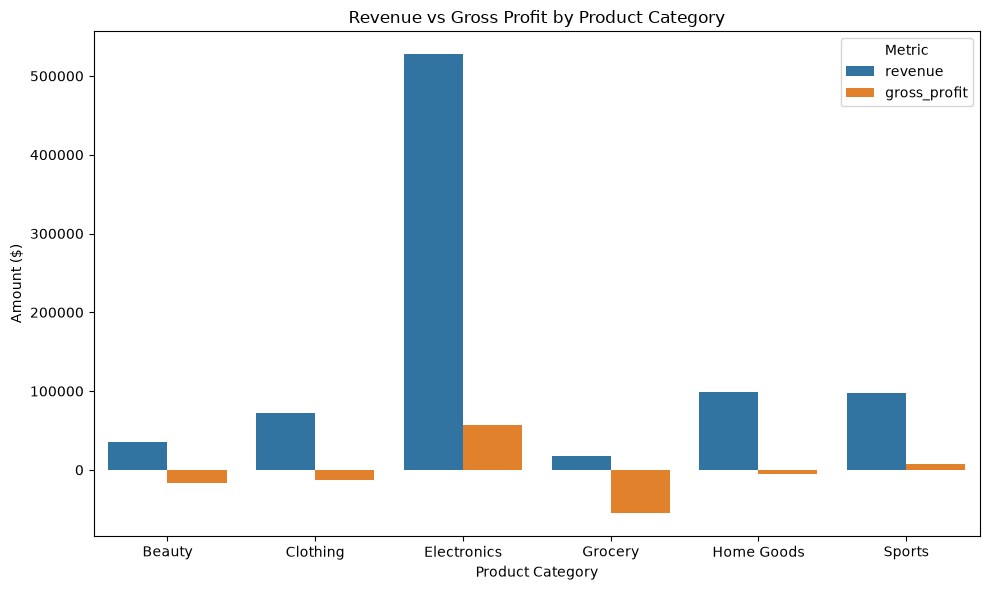

In [46]:
category_summary = (
    sales.groupby("product_category")[["revenue", "gross_profit"]]
    .sum()
    .reset_index()
)

category_long = category_summary.melt(
    id_vars="product_category",
    var_name="Metric",
    value_name="Amount"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=category_long,
    x="product_category",
    y="Amount",
    hue="Metric"
)

plt.title("Revenue vs Gross Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Amount ($)")

plt.tight_layout()
plt.show()

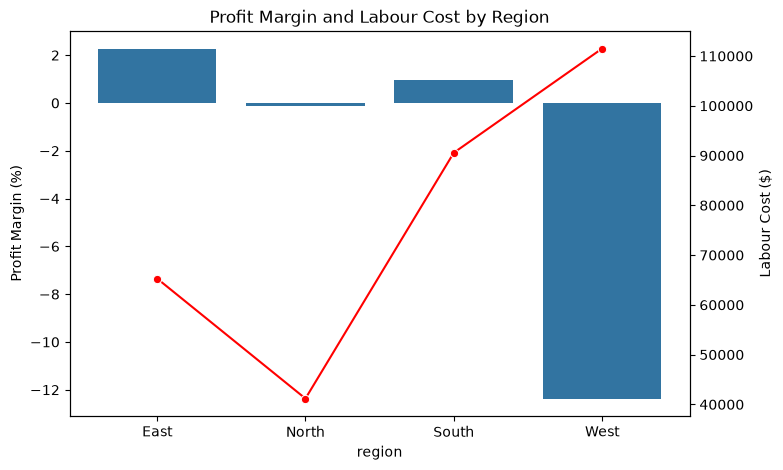

In [47]:
region_summary = (
    sales.groupby("region")
    .agg(
        revenue=("revenue","sum"),
        gross_profit=("gross_profit","sum"),
        labour_cost=("labour_cost","sum")
    )
)

region_summary["profit_margin"] = (
    region_summary["gross_profit"] /
    region_summary["revenue"] * 100
)

fig, ax1 = plt.subplots(figsize=(8,5))

sns.barplot(
    x=region_summary.index,
    y=region_summary["profit_margin"],
    ax=ax1
)

ax2 = ax1.twinx()

sns.lineplot(
    x=region_summary.index,
    y=region_summary["labour_cost"],
    marker="o",
    color="red",
    ax=ax2
)

ax1.set_ylabel("Profit Margin (%)")
ax2.set_ylabel("Labour Cost ($)")
ax1.set_title("Profit Margin and Labour Cost by Region")

plt.show()

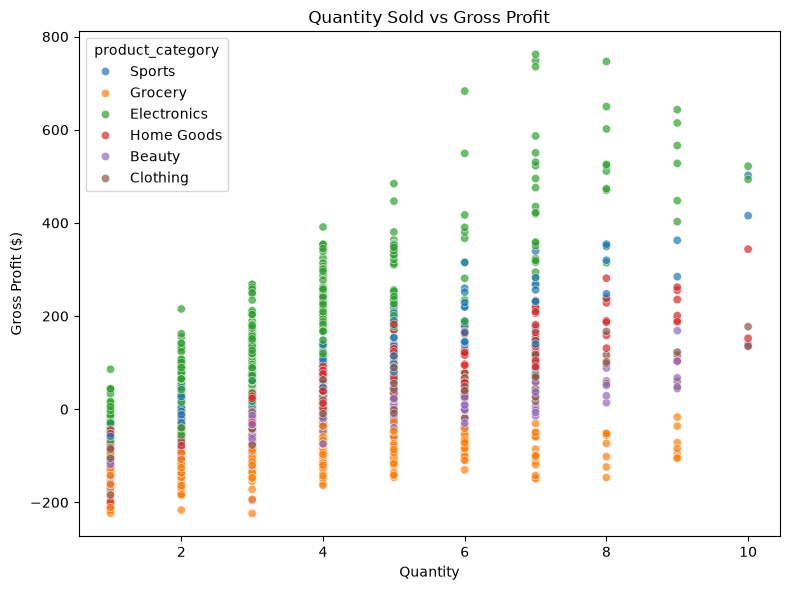

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sales,
    x="quantity",
    y="gross_profit",
    hue="product_category",
    alpha=0.7
)

plt.title("Quantity Sold vs Gross Profit")
plt.xlabel("Quantity")
plt.ylabel("Gross Profit ($)")

plt.tight_layout()
plt.show()

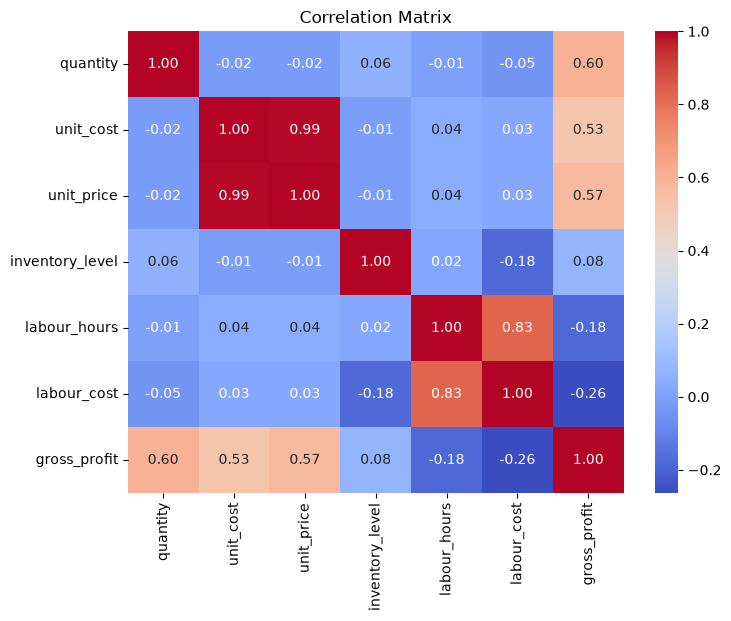

In [49]:
plt.figure(figsize=(8,6))

sns.heatmap(
    sales[[
        "quantity",
        "unit_cost",
        "unit_price",
        "inventory_level",
        "labour_hours",
        "labour_cost",
        "gross_profit"
    ]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

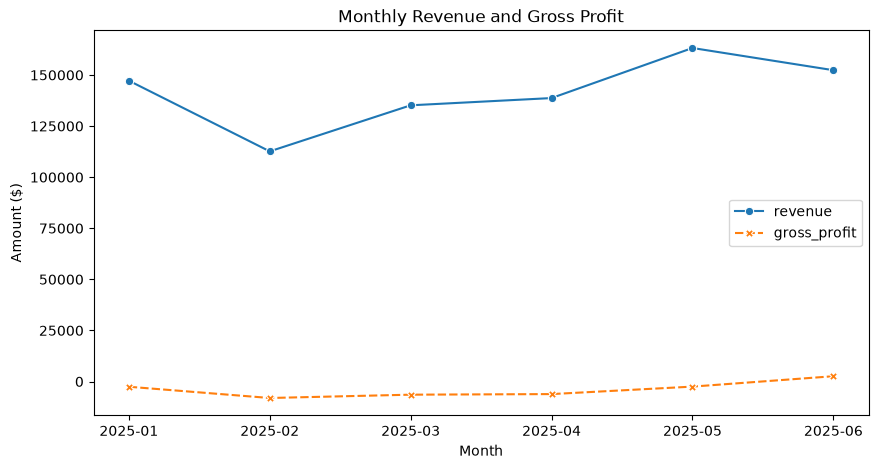

In [50]:
monthly = (
    sales.groupby(sales["sale_date"].dt.to_period("M"))
    [["revenue", "gross_profit"]]
    .sum()
)

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(10,5))

sns.lineplot(data=monthly, markers=True)

plt.title("Monthly Revenue and Gross Profit")
plt.xlabel("Month")
plt.ylabel("Amount ($)")

plt.show()

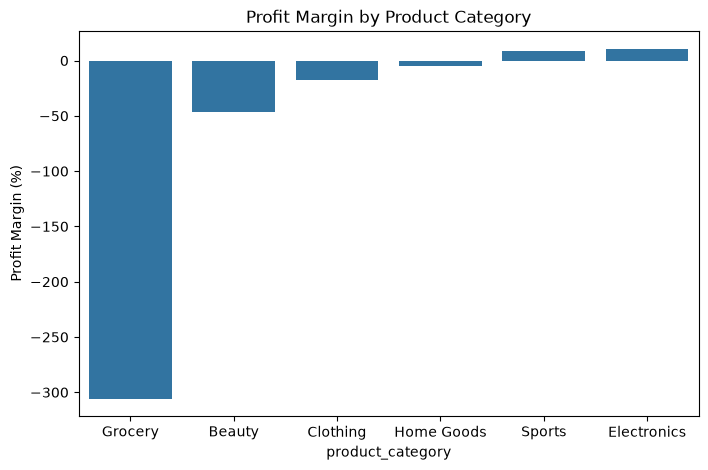

In [51]:
category = sales.groupby("product_category").agg(
    revenue=("revenue","sum"),
    profit=("gross_profit","sum")
)

category["profit_margin"] = (
    category["profit"]/category["revenue"]*100
)

category = category.sort_values("profit_margin")

plt.figure(figsize=(8,5))

sns.barplot(
    data=category.reset_index(),
    x="product_category",
    y="profit_margin"
)

plt.ylabel("Profit Margin (%)")
plt.title("Profit Margin by Product Category")

plt.show()

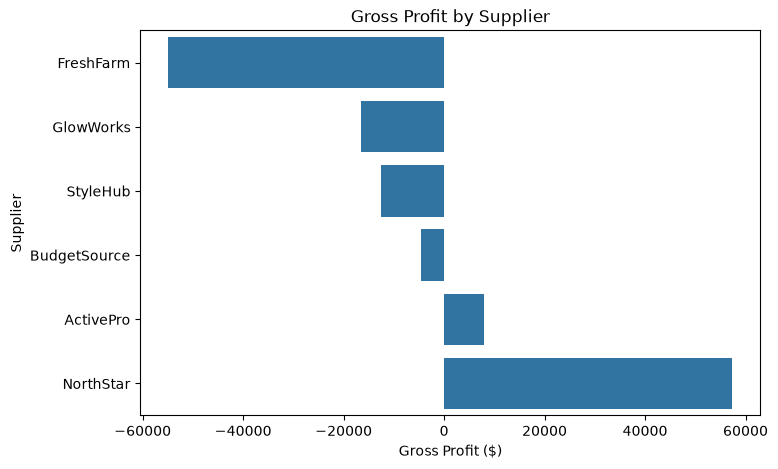

In [52]:
supplier = (
    sales.groupby("supplier")["gross_profit"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=supplier.values,
    y=supplier.index
)

plt.title("Gross Profit by Supplier")
plt.xlabel("Gross Profit ($)")
plt.ylabel("Supplier")

plt.show()

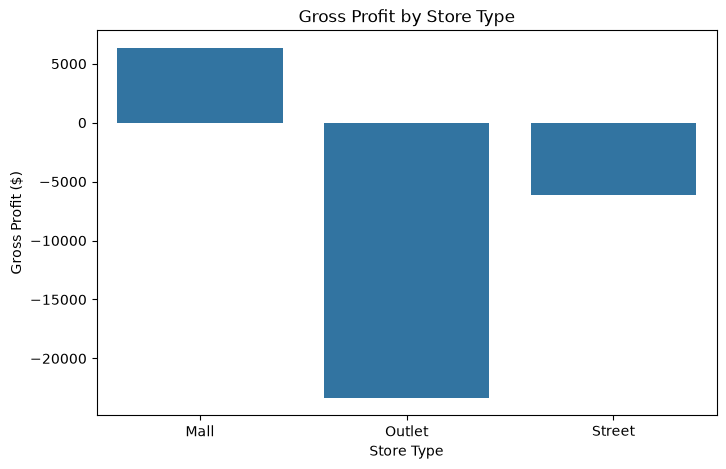

In [53]:
store_type = (
    sales.groupby("store_type")
    .agg(
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=store_type,
    x="store_type",
    y="gross_profit"
)

plt.title("Gross Profit by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Gross Profit ($)")

plt.show()

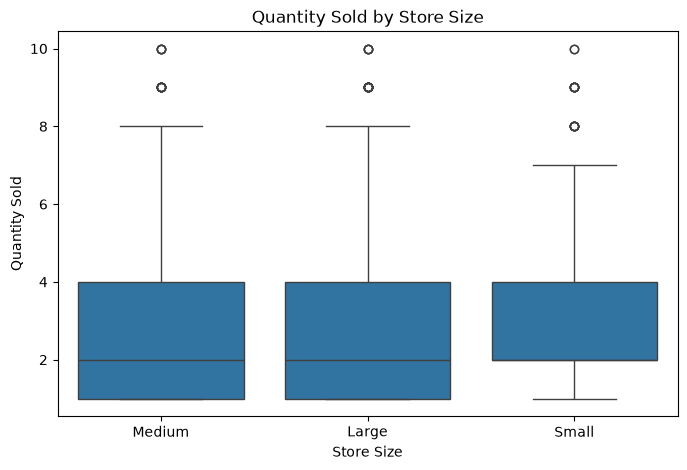

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=sales,
    x="store_size",
    y="quantity"
)

plt.title("Quantity Sold by Store Size")
plt.xlabel("Store Size")
plt.ylabel("Quantity Sold")

plt.show()

## Consulting Summary

Consulting Summary

After cleaning and merging the sales transaction data with the store information data, I analyzed ShopSmart Retail’s performance to understand why profits are not growing even though revenue appears healthy. After cleaning, the final dataset contained 2,581 records. Total revenue was \\$849,297.34, but total gross profit was -\\$23,134.39, meaning the company is generating sales but still losing money overall.

The first visualization compared revenue and gross profit by product category. Electronics generated the highest revenue and was also the most profitable category, with \\$57,332.00 in gross profit. Sports was also profitable, with \\$8,040.27 in gross profit. However, several categories had negative gross profit, especially Grocery, Beauty, Clothing, and Home Goods. Grocery was the biggest concern because it had the lowest revenue but the largest loss at -\\$54,858.38. This suggests that some product categories are dragging down the overall performance of the business.

The regional analysis showed that profitability also varies by region. The West region had the worst performance, with -\\$30,301.13 in gross profit and the lowest profit margin. This region also had the highest average labour cost per transaction, which suggests that labour expenses may be one of the main reasons profits are lower in that region. The East and South regions were slightly profitable, while the North region was close to break-even.

The scatterplot of quantity sold versus gross profit showed that larger transactions are generally more profitable. Transactions with lower quantities were more likely to lose money because labour cost is applied at the transaction level. This means smaller purchases may not bring in enough revenue to cover both the product cost and labour cost. The correlation matrix supported this pattern, showing that gross profit had a strong positive relationship with revenue and a moderate positive relationship with quantity sold. Labour cost and labour hours had negative relationships with gross profit.

The monthly revenue and gross profit trend showed that revenue remained fairly strong throughout the period, but profit was negative for most months. June was the only month with positive gross profit, which may suggest some improvement near the end of the period. However, the overall trend still shows that sales volume alone is not enough to guarantee profitability.

The profit margin by product category showed that Electronics and Sports were the strongest categories, while Grocery and Beauty had the weakest margins. Grocery was especially concerning because its profit margin was extremely negative, meaning the company is losing much more than it earns from that category. This could be caused by low selling prices, high supplier costs, labour costs, or a combination of these factors.

Supplier performance showed a similar pattern. NorthStar and ActivePro were the only suppliers associated with positive gross profit, while FreshFarm, GlowWorks, StyleHub, and BudgetSource were all associated with losses. FreshFarm had the largest negative gross profit, which aligns with the poor performance of the Grocery category. This suggests that management should review supplier pricing, product margins, and whether certain supplier relationships are still beneficial.

After merging in the store information dataset, store type also showed meaningful differences. Mall stores were the only store type with positive gross profit, at \\$6,336.30. Street stores were slightly unprofitable, while Outlet stores had the largest loss at -\\$23,357.26. This suggests that Outlet locations may have operational or pricing issues that should be investigated further.

The quantity sold by store size visualization showed that Small stores had the highest average quantity sold per transaction, followed by Large and then Medium stores. However, all store sizes still had negative gross profit overall. This suggests that store size alone does not explain profitability, but it may affect transaction patterns and sales volume.

Overall, ShopSmart Retail has healthy revenue, but profitability is being reduced by high labour costs, low-margin categories, and underperforming suppliers and store types. I would recommend that management review labour efficiency in the West region, investigate why Grocery and Beauty are generating large losses, reassess supplier relationships with FreshFarm and other low-performing suppliers, and take a closer look at Outlet stores since they had the largest loss by store type. The company should also focus on increasing higher-volume transactions because larger purchases are more likely to cover labour costs and generate positive profit.